# P&L Attribution — independent Black-Scholes input bumps

Every day the book sells a \$1M-notional 1Y call spread (short 100% strike, long 110%),
holding ~250 spreads at steady state. This notebook attributes each option's daily value
change to the **inputs of the Black-Scholes formula**, each computed **independently**
(single-input revaluation from the same previous-close base — not a sequential waterfall):

| component | what is bumped | notes |
|---|---|---|
| `equity` | spot \$S_0 \to S_1\$, vol held | split into `eq_delta`, `eq_gamma`, `eq_higher` |
| `vol` | the option's own implied vol \$\sigma_0 \to \sigma_1\$ | \$\sigma_1\$ looked up at the *new* date/TTM/moneyness, so this carries surface change + term roll + smile slide |
| `rate` | zero rate \$r\$ (from the discount curve) at old TTM | |
| `div` | implied dividend yield \$q\$ (from forward vs spot) at old TTM | |
| `time` | TTM shrinks, everything else held | |
| `vanna` | exact spot–vol cross: \$V(S_1,\sigma_1) - V(S_1,\sigma_0) - V(S_0,\sigma_1) + V_0\$ | |
| `resid` | actual P&L − sum of the above | remaining cross terms; should be **small** |

Conventions: ACT/365, vols as decimals, marks on the pillar grid (8 TTMs × 13 moneyness),
settlement at intrinsic. Daily totals match `simulate_book` exactly (tested).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vol_pca import load_surfaces
from vol_pca.attribution import independent_attribution

# fixed component -> color map (validated palette, light mode), used in every chart
C = {"pl": "#0b0b0b", "equity": "#2a78d6", "vol": "#eb6834", "time": "#1baf7a",
     "vanna": "#eda100", "rate": "#e87ba4", "div": "#008300", "resid": "#e34948"}
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "legend.frameon": False,
})

sd = load_surfaces("SPX_volSurface 2.csv")
res, _ = independent_attribution(sd)
normal = res["gap_days"] <= 7   # exclude the two month-long data gaps from daily stats
print(f"{len(res)} P&L days, {res['n_spreads'].iloc[-1]} spreads at end, "
      f"{(~normal).sum()} gap days excluded from daily stats")

3140 P&L days, 258 spreads at end, 2 gap days excluded from daily stats


## Component summary

Daily standard deviations are the key exhibit: the residual should be small next to the
components it could be hiding in — total P&L, `equity`, and `vol`.

In [2]:
COMPS = ["equity", "vol", "time", "vanna", "rate", "div", "resid"]
EQ = ["eq_delta", "eq_gamma", "eq_higher"]

t = res.loc[normal]
summ = pd.DataFrame({
    "total ($M)": res[["pl"] + COMPS + EQ].sum() / 1e6,
    "daily mean ($k)": t[["pl"] + COMPS + EQ].mean() / 1e3,
    "daily std ($k)": t[["pl"] + COMPS + EQ].std() / 1e3,
})
summ["std as % of P&L std"] = 100 * summ["daily std ($k)"] / summ.loc["pl", "daily std ($k)"]
print(summ.round(1).to_string())
print(f"\nresidual std / total P&L std : {t['resid'].std() / t['pl'].std():6.1%}")
print(f"residual std / vol comp std  : {t['resid'].std() / t['vol'].std():6.1%}")

           total ($M)  daily mean ($k)  daily std ($k)  std as % of P&L std
pl              -80.0            -24.2           663.7                100.0
equity          -78.8            -23.9           658.9                 99.3
vol              -2.2             -0.5            69.0                 10.4
time             17.2              5.3            17.8                  2.7
vanna           -15.2             -4.8            27.4                  4.1
rate             -0.7             -0.2             9.7                  1.5
div              -0.2             -0.0            35.3                  5.3
resid            -0.1              0.0             5.2                  0.8
eq_delta        -79.9            -24.4           661.2                 99.6
eq_gamma          2.5              0.9            52.9                  8.0
eq_higher        -1.3             -0.4            12.5                  1.9

residual std / total P&L std :   0.8%
residual std / vol comp std  :   7.5%


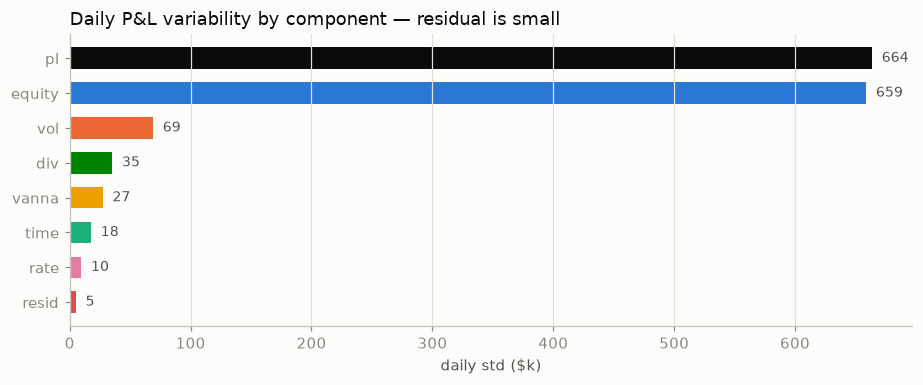

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
order = t[COMPS + ["pl"]].std().sort_values()
bars = ax.barh(order.index, order / 1e3,
               color=[C.get(c, "#898781") for c in order.index], height=0.62)
for b, v in zip(bars, order / 1e3):
    ax.text(v + order.max() / 1e3 * 0.012, b.get_y() + b.get_height() / 2,
            f"{v:,.0f}", va="center", fontsize=9, color="#52514e")
ax.set_xlabel("daily std ($k)")
ax.set_title("Daily P&L variability by component — residual is small", loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## Cumulative P&L by component

`rate` and `div` are negligible cumulatively (totals in the table above), so the chart
shows the four components that matter plus the total.

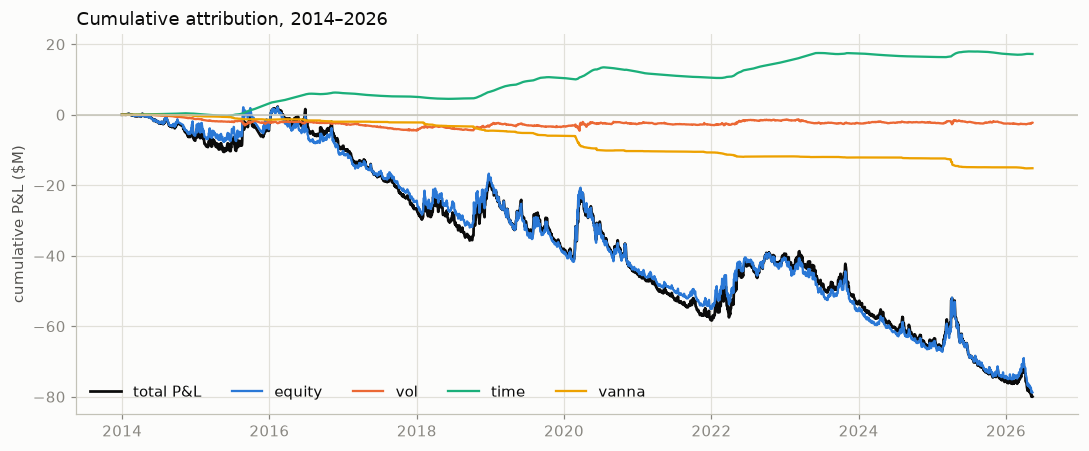

In [4]:
cum = res[["pl", "equity", "vol", "time", "vanna"]].cumsum() / 1e6
fig, ax = plt.subplots()
for col in cum.columns:
    ax.plot(cum.index, cum[col], color=C[col], lw=1.8 if col == "pl" else 1.5,
            label="total P&L" if col == "pl" else col)
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_ylabel("cumulative P&L ($M)")
ax.set_title("Cumulative attribution, 2014–2026", loc="left")
ax.legend(loc="lower left", ncols=5)
plt.tight_layout(); plt.show()

## Reconstruction quality

Summing the independent components (without the residual) should reproduce actual daily
P&L almost exactly.

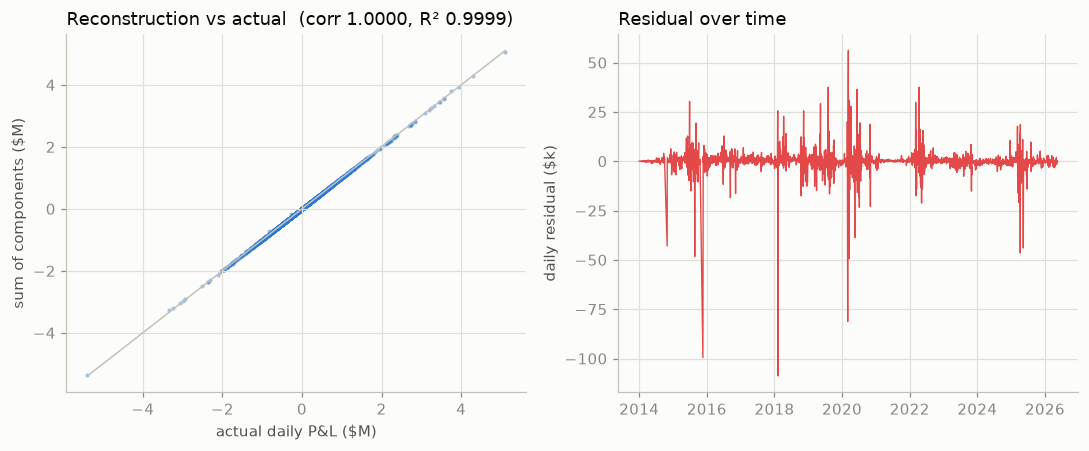

In [5]:
recon = t[COMPS[:-1]].sum(axis=1)
corr = np.corrcoef(t["pl"], recon)[0, 1]
r2 = 1 - (t["pl"] - recon).var() / t["pl"].var()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
lim = np.array([t["pl"].min(), t["pl"].max()]) / 1e6
axes[0].plot(lim, lim, color="#c3c2b7", lw=1)
axes[0].scatter(t["pl"] / 1e6, recon / 1e6, s=7, color=C["equity"], alpha=0.45, lw=0)
axes[0].set_xlabel("actual daily P&L ($M)")
axes[0].set_ylabel("sum of components ($M)")
axes[0].set_title(f"Reconstruction vs actual  (corr {corr:.4f}, R² {r2:.4f})", loc="left")

axes[1].plot(res.index, res["resid"] / 1e3, color=C["resid"], lw=0.9)
axes[1].set_ylabel("daily residual ($k)")
axes[1].set_title("Residual over time", loc="left")
plt.tight_layout(); plt.show()

## Where the residual comes from

The biggest residual days are stress days — large simultaneous spot and vol moves make
the unattributed higher-order cross terms (beyond vanna) briefly visible, plus settlement
pin risk on legs expiring into a gap move.

A diagnostic bonus: on 2018-02-07 the `div` component swings ~−\$0.9M. Backing out the
implied dividend yield shows the 2018-02-06 forward curve is inconsistent with the quoted
spot (short-end q spikes to 16% vs ~2–3% on neighboring days — forward and spot snapped
at different times during the VIX blow-up), normalizing the next day. The independent
decomposition routes that data artifact into `div` and flags it, instead of hiding it in
the residual.

In [6]:
worst_days = res.loc[res["resid"].abs().sort_values(ascending=False).index[:10],
                     ["spot", "pl", "equity", "vol", "vanna", "resid"]]
print((worst_days / 1e3).round(0).to_string())

            spot      pl  equity    vol  vanna  resid
date                                                 
2018-02-07   3.0  -839.0   323.0 -177.0   37.0 -109.0
2018-02-06   3.0  -277.0 -1137.0  -63.0   59.0 -105.0
2015-11-20   2.0 -2965.0 -2778.0 -602.0   -5.0 -100.0
2020-03-02   3.0 -3349.0 -3109.0  196.0 -395.0  -81.0
2020-03-09   3.0  5111.0  4992.0  308.0 -434.0   56.0
2020-03-16   2.0  3751.0  4120.0  -29.0 -421.0  -49.0
2015-08-24   2.0  2310.0  2530.0 -345.0   27.0  -48.0
2025-04-09   5.0 -5392.0 -5390.0  656.0 -624.0  -46.0
2025-05-12   6.0 -2944.0 -2879.0  103.0 -153.0  -44.0
2014-10-30   2.0  -928.0  -911.0 -135.0   37.0  -43.0


In [7]:
worst = res["resid"].abs().idxmax()
_, details = independent_attribution(sd, detail_dates=[worst.to_datetime64()])
det = details[worst]
print(f"per-leg detail, {worst.date()}  ({len(det)} legs, "
      f"{int(det['settled'].sum())} settled)\n")
cols = ["strike", "units", "ttm0", "mon0", "mon1", "sig0", "sig1",
        "pl", "equity", "vol", "vanna", "resid"]
top = det.reindex(det["resid"].abs().sort_values(ascending=False).index)
print(top[cols].head(8).round(2).to_string())
print("\nday totals ($k):")
print((det[["pl", "equity", "vol", "time", "vanna", "rate", "div", "resid"]]
       .sum() / 1e3).round(0).to_string())

per-leg detail, 2018-02-07  (522 legs, 2 settled)

     strike   units  ttm0   mon0   mon1  sig0  sig1       pl   equity     vol   vanna    resid
2   2294.67 -435.79  0.01  85.14  85.57  0.52  0.41  2478.42  5856.77    0.16    0.13  1703.79
1   2522.39  436.09  0.00  93.59  94.06  0.38  0.38 -4176.15 -5865.18    0.00    0.00 -1703.25
0   2293.08 -436.09  0.00  85.08  85.51  0.52  0.52  4168.22  5869.75   -0.00   -0.00  1699.37
4   2307.87 -433.30  0.01  85.63  86.06  0.51  0.40   796.62  5811.17    6.94    3.38  1691.33
6   2316.10 -431.76  0.01  85.94  86.37  0.50  0.40  -830.95  5767.67   46.00   16.07  1648.55
3   2524.14  435.79  0.01  93.66  94.13  0.38  0.27 -2614.51 -5770.42 -126.39  -79.30 -1553.72
8   2328.25 -429.51  0.02  86.39  86.82  0.50  0.39 -5212.71  5592.05  546.85  101.14  1315.16
10  2337.58 -427.79  0.02  86.73  87.17  0.49  0.39 -6430.08  5493.28  882.19  139.48  1144.77

day totals ($k):
pl       -839.0
equity    323.0
vol      -177.0
time      -13.0
vanna      3

## Takeaways

- The independent-bump decomposition closes: residual daily std is a small fraction of
  total P&L std (table above), and cumulative residual is small next to `equity`/`vol`.
- `vanna` is a real, persistently negative component — SPX spot-down/vol-up correlation
  acting on the book's spot–vol cross — and must be attributed explicitly or it poisons
  the residual.
- `equity` is almost entirely `eq_delta` + `eq_gamma`; higher-order spot terms only show
  up on crash days.
- `rate` is negligible at this horizon. `div` is small cumulatively but spiky — its
  spikes diagnose forward-vs-spot snap inconsistencies in the data (e.g. 2018-02-06)
  rather than real dividend moves.

Next: the PCA factor model (`scripts/run_analysis.py`) targets the vol component —
factor exposures × daily factor moves vs the full per-option vol revaluation.